# 02 — GraphSAGE Node Embeddings (PyTorch Geometric)

Build a PyG graph from the processed data, train a 2-layer GraphSAGE model
via unsupervised link prediction, and extract 64-dim node embeddings.

In [ ]:
import os
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import SAGEConv
from torch_geometric.loader import LinkNeighborLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# ── Pipeline integration ──────────────────────────────────────────
_RUN_DIR = os.environ.get("AML_RUN_DIR", "")
DATA_DIR = os.path.join(_RUN_DIR, "data") if _RUN_DIR else "data"
EMBEDDINGS_DIR = os.path.join(_RUN_DIR, "embeddings") if _RUN_DIR else "embeddings"
MODELS_DIR = os.path.join(_RUN_DIR, "models") if _RUN_DIR else "models"

os.makedirs(EMBEDDINGS_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

print(f"Data dir:       {os.path.abspath(DATA_DIR)}")
print(f"Embeddings dir: {os.path.abspath(EMBEDDINGS_DIR)}")
print(f"Models dir:     {os.path.abspath(MODELS_DIR)}")

## Hyperparameters

In [ ]:
EMBEDDING_DIM = 64
HIDDEN_DIM = 128
NUM_NEIGHBORS = [15, 10]    # neighbors to sample per hop (2-hop)
BATCH_SIZE = 256
EPOCHS = int(os.environ.get("AML_EPOCHS", "10"))
LEARNING_RATE = 0.001
NEG_SAMPLING_RATIO = 1.0    # 1 negative per positive edge
DROPOUT = 0.3

print(f"Epochs: {EPOCHS}")

## 1. Load Processed Data

In [ ]:
node_features = pd.read_parquet(os.path.join(DATA_DIR, "node_features.parquet"))
edges = pd.read_parquet(os.path.join(DATA_DIR, "edges.parquet"))

print(f"Nodes: {len(node_features):,}")
print(f"Edges: {len(edges):,}")

## 2. Build Node ID Mapping

In [17]:
unique_nodes = node_features["id"].values
node_to_idx = {nid: i for i, nid in enumerate(unique_nodes)}
idx_to_node = {i: nid for nid, i in node_to_idx.items()}

print(f"Node mapping: {len(node_to_idx)} nodes")

Node mapping: 7500 nodes


## 3. Build PyG Data Object

In [18]:
# Build edge_index
src_indices = edges["source"].map(node_to_idx).values
dst_indices = edges["target"].map(node_to_idx).values
edge_index = torch.tensor(np.array([src_indices, dst_indices]), dtype=torch.long)

# Build node feature matrix
feature_cols = [
    "type", "in_degree", "out_degree",
    "total_amount_sent", "total_amount_received",
    "avg_amount_sent", "avg_amount_received",
    "unique_counterparties_sent", "unique_counterparties_received",
]
x = torch.tensor(node_features[feature_cols].values, dtype=torch.float32)

# Normalize features (StandardScaler)
x_mean = x.mean(dim=0)
x_std = x.std(dim=0).clamp(min=1e-8)
x = (x - x_mean) / x_std

# Create PyG Data
data = Data(x=x, edge_index=edge_index, num_nodes=len(unique_nodes))

print(f"Data: {data}")
print(f"  x shape:          {data.x.shape}")
print(f"  edge_index shape: {data.edge_index.shape}")

Data: Data(x=[7500, 9], edge_index=[2, 67100], num_nodes=7500)
  x shape:          torch.Size([7500, 9])
  edge_index shape: torch.Size([2, 67100])


## 4. Define GraphSAGE Model

In [19]:
class GraphSAGE(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, dropout=0.3):
        super().__init__()
        self.conv1 = SAGEConv(in_channels, hidden_channels)
        self.conv2 = SAGEConv(hidden_channels, out_channels)
        self.dropout = dropout

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv2(x, edge_index)
        return x

    @torch.no_grad()
    def full_forward(self, x, edge_index):
        """Get embeddings for all nodes at inference time."""
        self.eval()
        return self.forward(x, edge_index)


model = GraphSAGE(data.num_node_features, HIDDEN_DIM, EMBEDDING_DIM, DROPOUT).to(device)
print(model)
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")

GraphSAGE(
  (conv1): SAGEConv(9, 128, aggr=mean)
  (conv2): SAGEConv(128, 64, aggr=mean)
)
Total parameters: 18,880


## 5. Set Up Unsupervised Link Prediction Training

In [20]:
train_loader = LinkNeighborLoader(
    data,
    num_neighbors=NUM_NEIGHBORS,
    batch_size=BATCH_SIZE,
    edge_label_index=data.edge_index,
    neg_sampling_ratio=NEG_SAMPLING_RATIO,
    shuffle=True,
)

print(f"Number of batches: {len(train_loader)}")

Number of batches: 263


/opt/miniconda/envs/amgan2/lib/python3.10/site-packages/torch_geometric/loader/link_neighbor_loader.py:252: UserWarning: Using 'NeighborSampler' without a 'pyg-lib' installation is deprecated and will be removed soon. Please install 'pyg-lib' for accelerated neighborhood sampling
  neighbor_sampler = NeighborSampler(


## 6. Training Loop

In [21]:
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
history = {"loss": []}

for epoch in range(1, EPOCHS + 1):
    model.train()
    total_loss = 0
    total_examples = 0

    for batch in train_loader:
        batch = batch.to(device)
        optimizer.zero_grad()

        # Forward pass — get embeddings for all nodes in the batch
        h = model(batch.x, batch.edge_index)

        # Score edges via dot product
        src_emb = h[batch.edge_label_index[0]]
        dst_emb = h[batch.edge_label_index[1]]
        pred = (src_emb * dst_emb).sum(dim=-1)

        # Binary cross-entropy loss (positive edges=1, negative edges=0)
        loss = F.binary_cross_entropy_with_logits(pred, batch.edge_label.float())
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * pred.size(0)
        total_examples += pred.size(0)

    avg_loss = total_loss / total_examples
    history["loss"].append(avg_loss)
    print(f"Epoch {epoch:2d}/{EPOCHS}  Loss: {avg_loss:.4f}")

Epoch  1/10  Loss: 101.0782
Epoch  2/10  Loss: 18.8620
Epoch  3/10  Loss: 7.0910
Epoch  4/10  Loss: 2.9654
Epoch  5/10  Loss: 1.5058
Epoch  6/10  Loss: 0.9512
Epoch  7/10  Loss: 0.7197
Epoch  8/10  Loss: 0.6184
Epoch  9/10  Loss: 0.5540
Epoch 10/10  Loss: 0.5183


## 7. Training Loss Curve

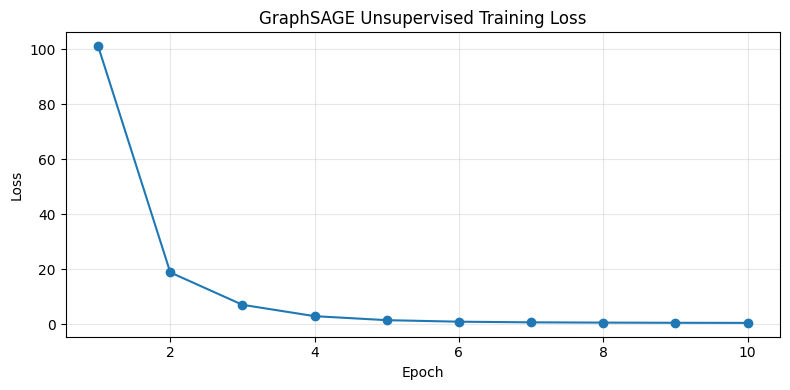

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(range(1, EPOCHS + 1), history["loss"], marker="o")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("GraphSAGE Unsupervised Training Loss")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Extract Node Embeddings

In [23]:
data_dev = data.to(device)
embeddings = model.full_forward(data_dev.x, data_dev.edge_index).cpu().numpy()

# Free GPU memory immediately — no longer needed
del data_dev
torch.cuda.empty_cache()

print(f"Embeddings shape: {embeddings.shape}  (nodes x dims)")

Embeddings shape: (7500, 64)  (nodes x dims)


## 9. Save Embeddings

In [ ]:
np.save(os.path.join(EMBEDDINGS_DIR, "node_embeddings.npy"), embeddings)
np.save(os.path.join(EMBEDDINGS_DIR, "node_ids.npy"), unique_nodes)

# Also save as parquet for convenience
emb_df = pd.DataFrame(embeddings, columns=[f"emb_{i}" for i in range(EMBEDDING_DIM)])
emb_df["id"] = unique_nodes
emb_df.to_parquet(os.path.join(EMBEDDINGS_DIR, "node_embeddings.parquet"), index=False)

# Save the model
torch.save(model.state_dict(), os.path.join(MODELS_DIR, "graphsage.pt"))

# Save normalization params for inference
torch.save({"mean": x_mean, "std": x_std}, os.path.join(MODELS_DIR, "feature_norm.pt"))

print(f"Saved: {EMBEDDINGS_DIR}/node_embeddings.npy")
print(f"Saved: {EMBEDDINGS_DIR}/node_ids.npy")
print(f"Saved: {EMBEDDINGS_DIR}/node_embeddings.parquet")
print(f"Saved: {MODELS_DIR}/graphsage.pt")
print(f"Saved: {MODELS_DIR}/feature_norm.pt")

In [ ]:
# ── GPU Cleanup — free VRAM before quality check / next notebook ──
del model, data, train_loader, edge_index, x
if "data_dev" in dir():
    del data_dev
torch.cuda.empty_cache()
import gc; gc.collect()

print(f"GPU memory freed: {torch.cuda.memory_allocated()/1e6:.1f} MB allocated, {torch.cuda.memory_reserved()/1e6:.1f} MB reserved")

NameError: name 'model' is not defined

: 

## 10. Quality Check — Logistic Regression on SAR Labels

In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

# Get SAR labels aligned with embeddings
is_sar = node_features["is_sar"].values

X_train_lr, X_test_lr, y_train_lr, y_test_lr = train_test_split(
    embeddings, is_sar, test_size=0.2, random_state=42, stratify=is_sar
)

clf = LogisticRegression(max_iter=1000, class_weight="balanced")
clf.fit(X_train_lr, y_train_lr)

y_pred = clf.predict(X_test_lr)
y_prob = clf.predict_proba(X_test_lr)[:, 1]

print(f"Accuracy:  {accuracy_score(y_test_lr, y_pred):.4f}")
print(f"ROC AUC:   {roc_auc_score(y_test_lr, y_prob):.4f}")
print()
print(classification_report(y_test_lr, y_pred, target_names=["Non-SAR", "SAR"]))

Accuracy:  0.9060
ROC AUC:   0.9463

              precision    recall  f1-score   support

     Non-SAR       0.98      0.91      0.95      1371
         SAR       0.47      0.84      0.61       129

    accuracy                           0.91      1500
   macro avg       0.73      0.88      0.78      1500
weighted avg       0.94      0.91      0.92      1500

